In [1]:
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [2]:
# function to extract data from bbh simulations

def get_simulation_data(filepath):
 
    with open(filepath, 'r') as file:
        lines = file.readlines()
        
    init_line = [line for line in lines if line.startswith("# Initial Conditions")][0]
    
    q_match = re.search(r'q=([0-9.]+)', init_line)
    chi1_match = re.search(r'χ1=([0-9.]+)', init_line)
    chi2_match = re.search(r'χ2=([0-9.]+)', init_line)

    q = float(q_match.group(1)) if q_match else 1.0
    chi1_mag = float(chi1_match.group(1)) if chi1_match else 0.0
    chi2_mag = float(chi2_match.group(1)) if chi2_match else 0.0
    
    print(f"Extracted initial conditions: q={q}, chi1={chi1_mag}, chi2={chi2_mag}")


    df = pd.read_csv(filepath, comment='#')
    
    time_steps = df['time_M'].values
    orbital_separation = df['separation_M'].values
    theta1 = df['theta1_rad'].values
    theta2 = df['theta2_rad'].values
    deltaphi = df['deltaphi_rad'].values
    L_mag_sim = df['angular_momentum_L'].values
    chi_eff_sim = df['effective_spin_chi_eff'].values
    
    chi1_parallel = chi1_mag * np.cos(theta1)
    chi2_parallel = chi2_mag * np.cos(theta2)
    
    return {
        'time': time_steps,
        'q': q,
        'chi1_mag': chi1_mag,
        'chi2_mag': chi2_mag,
        'chi1_parallel': chi1_parallel,
        'chi2_parallel': chi2_parallel,
        'separation': orbital_separation,
        'theta1': theta1,
        'theta2': theta2,
        'deltaphi': deltaphi,
        'L_mag_numerical': L_mag_sim,
        'chi_eff_numerical': chi_eff_sim
    }

In [3]:
filepath = "/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q:0.40_χ1:0.20_χ2:0.20_θ1:45_θ2:45_ΔΦ:90.csv"

data = get_simulation_data(filepath)

Extracted initial conditions: q=0.4, chi1=0.2, chi2=0.2


In [4]:
# function to compute the final state

def compute_final_state(m1, m2, chi1_vec, chi2_vec, L_hat, chi_eff=None):
    M = m1 + m2
    eta = (m1 * m2) / (M ** 2)
    
    if chi_eff is None:
        chi_eff = (m1 * np.dot(chi1_vec, L_hat) + m2 * np.dot(chi2_vec, L_hat)) / M
        
    # final mass
    p0, p1, p2 = 0.04826, 0.01559, 0.00485
    E_rad = eta * (p0 + p1 * chi_eff + p2 * chi_eff**2)
    M_f = M * (1.0 - E_rad) 
    
    # final spin
    t0, t1, t2, t3 = -2.8904, -0.2181, 3.328, 3.205
    l_isco = 2.0 * np.sqrt(3.0) + t0 * eta + t1 * eta**2 + \
             t2 * chi_eff * eta + t3 * (chi_eff**2) * eta
             
    L_vec = l_isco * eta * L_hat
    S_tot_vec = (m1**2 / M**2) * chi1_vec + (m2**2 / M**2) * chi2_vec
    
    J_fin_vec = S_tot_vec + L_vec
    
    M_f_ratio = M_f / M
    a_f = np.linalg.norm(J_fin_vec) / (M_f_ratio ** 2)
    a_f_safe = min(a_f, 0.999999)
    
    return {'a_f': a_f_safe, 'M_f': M_f}

In [5]:
# function to calculate Bekenstein-Hawking entropy

def compute_entropy(M_f, a_f):
    Area = 8 * np.pi * (M_f ** 2) * (1 + np.sqrt(1 - a_f ** 2))
    return Area / 4.0

In [6]:
# function to map the evolution

def analyze_entropy_evolution(filepath):
    
    sim_data = get_simulation_data(filepath)
    n_steps = len(sim_data['time'])
    
    q = sim_data['q']
    m1 = 1.0 / (1.0 + q)
    m2 = q / (1.0 + q)
    
    chi1_vecs = np.zeros((n_steps, 3))
    chi1_vecs[:, 0] = sim_data['chi1_mag'] * np.sin(sim_data['theta1'])
    chi1_vecs[:, 2] = sim_data['chi1_parallel']
    
    chi2_vecs = np.zeros((n_steps, 3))
    chi2_vecs[:, 0] = sim_data['chi2_mag'] * np.sin(sim_data['theta2']) * np.cos(sim_data['deltaphi'])
    chi2_vecs[:, 1] = sim_data['chi2_mag'] * np.sin(sim_data['theta2']) * np.sin(sim_data['deltaphi'])
    chi2_vecs[:, 2] = sim_data['chi2_parallel']
    
    l_hat_vecs = np.tile(np.array([0.0, 0.0, 1.0]), (n_steps, 1))
    chi_eff_arr = sim_data['chi_eff_numerical']
    
    m_f_arr = np.zeros(n_steps)
    a_f_arr = np.zeros(n_steps)
    entropy_arr = np.zeros(n_steps)
    
    for i in range(n_steps):
        final_state = compute_final_state(
            m1, m2, 
            chi1_vecs[i], chi2_vecs[i], 
            l_hat_vecs[i], 
            chi_eff_arr[i]
        )
        
        a_f_arr[i] = final_state['a_f']
        m_f_arr[i] = final_state['M_f']
        
        entropy_arr[i] = compute_entropy(m_f_arr[i], a_f_arr[i])
        
    sim_data['predicted_M_f'] = m_f_arr
    sim_data['predicted_a_f'] = a_f_arr
    sim_data['predicted_entropy'] = entropy_arr
    
    return sim_data

In [7]:
sim_data = analyze_entropy_evolution(filepath)

Extracted initial conditions: q=0.4, chi1=0.2, chi2=0.2


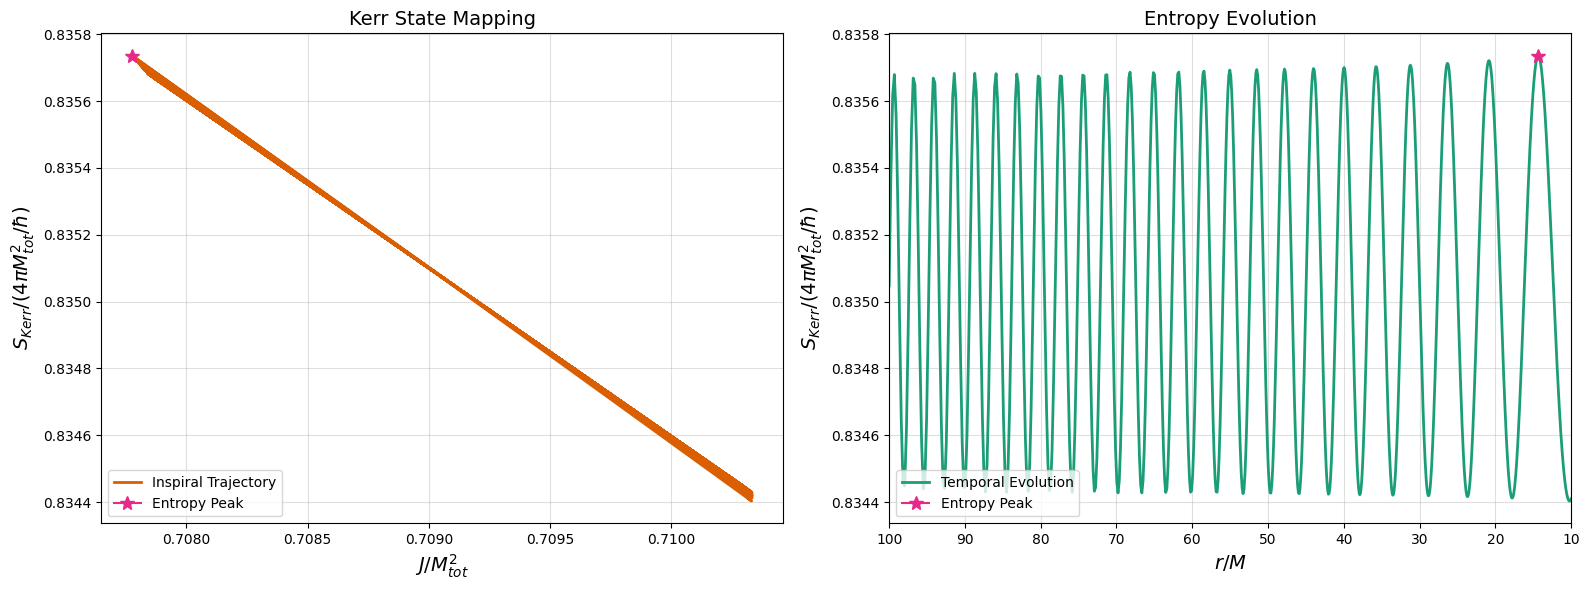

In [8]:
# graphs

sep = sim_data['separation']
a_f = sim_data['predicted_a_f']
S_norm = sim_data['predicted_entropy'] / (4 * np.pi) 
    
max_idx = np.argmax(S_norm)
S_max = S_norm[max_idx]
a_f_max = a_f[max_idx]
sep_max = sep[max_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
# Graph 1
ax1.plot(a_f, S_norm, color='#d95f02', lw=2, label='Inspiral Trajectory')
ax1.plot(a_f_max, S_max, marker='*', markersize=10, color='#e7298a', label='Entropy Peak')
ax1.set_xlabel(r'$J/M_{tot}^2$', fontsize=14)
ax1.set_ylabel(r'$S_{Kerr} / (4\pi M_{tot}^2 / \hbar)$', fontsize=14)
ax1.grid(True, alpha=0.4)
ax1.legend(loc='lower left')
ax1.set_title('Kerr State Mapping', fontsize=14)

# Graph 2
ax2.plot(sep, S_norm, color='#1b9e77', lw=2, label='Temporal Evolution')
ax2.plot(sep_max, S_max, marker='*', markersize=10, color='#e7298a',label='Entropy Peak')   
ax2.set_xlabel(r'$r/M$', fontsize=14)
ax2.set_ylabel(r'$S_{Kerr} / (4\pi M_{tot}^2 / \hbar)$', fontsize=14)
ax2.set_xlim(max(sep), min(sep)) 
ax2.grid(True, alpha=0.4)
ax2.legend(loc='lower left')
ax2.set_title('Entropy Evolution', fontsize=14)

plt.tight_layout()
plt.show()